In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("STEP 1: GENERATING SAMPLE DATA")

np.random.seed(42)
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

STEP 1: GENERATING SAMPLE DATA


In [5]:
n_transactions = 2000
transactions = []
categories = ['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Books']
products = {
    'Electronics': ['Laptop', 'Smartphone', 'Headphones', 'Tablet', 'Monitor'],
    'Clothing': ['T-Shirt', 'Jeans', 'Jacket', 'Shoes', 'Dress'],
    'Home & Garden': ['Lamp', 'Chair', 'Plant', 'Rug', 'Bedding'],
    'Sports': ['Running Shoes', 'Yoga Mat', 'Dumbbell', 'Bicycle', 'Tennis Racket'],
    'Books': ['Fiction', 'Science', 'Self-Help', 'History', 'Mystery']
}

In [6]:
for _ in range(n_transactions):
    date = pd.Timestamp(np.random.choice(date_range))
    if date.month in [10, 11, 12]:
        quantity = np.random.randint(1, 6)
    else:
        quantity = np.random.randint(1, 4)

    price_ranges = {
        'Electronics': (500, 1500),
        'Clothing': (20, 100),
        'Home & Garden': (30, 300),
        'Sports': (50, 500),
        'Books': (10, 50)
    }

    customer_type = np.random.choice(['Return', 'New'], p=[0.4, 0.6])
    customer_id = f"CUST_{np.random.randint(1000, 5000)}"

    category = np.random.choice(categories, p=[0.40, 0.25, 0.15, 0.12, 0.08])
    product = np.random.choice(products[category])
    unit_price = np.random.uniform(*price_ranges[category])

    transactions.append({
        'Date': date,
        'Customer_ID': customer_id,
        'Customer_Type': customer_type,
        'Category': category,
        'Product': product,
        'Quantity': quantity,
        'Unit_Price': round(unit_price, 2),
        'Total_Sale': round(unit_price * quantity, 2)
    })

print(len(transactions))

2000


In [9]:
df = pd.DataFrame(transactions)
df = df.sort_values('Date').reset_index(drop=True)

print(f"\n✓ Generated {len(df)} transactions")
print(f"✓ Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())


✓ Generated 2000 transactions
✓ Date range: 2023-01-01 to 2023-12-31

First 5 rows:
        Date Customer_ID Customer_Type       Category     Product  Quantity  \
0 2023-01-01   CUST_2539           New  Home & Garden       Plant         1   
1 2023-01-01   CUST_3514           New    Electronics      Laptop         3   
2 2023-01-01   CUST_3238        Return    Electronics  Smartphone         3   
3 2023-01-02   CUST_3000        Return    Electronics  Headphones         1   
4 2023-01-02   CUST_1912           New  Home & Garden     Bedding         2   

   Unit_Price  Total_Sale  
0      218.51      218.51  
1      535.17     1605.52  
2     1012.65     3037.96  
3      861.27      861.27  
4      237.75      475.50  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2000 non-null   datetime64[ns

In [10]:
print("STEP 2: DATA EXPLORATION & CLEANING")

print(df.describe())

print(f"\nData Quality:")
print(f"  • Total transactions: {len(df)}")
print(f"  • Date range: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"  • Unique customers: {df['Customer_ID'].nunique()}")
print(f"  • Unique products: {df['Product'].nunique()}")
print(f"  • Total revenue: ${df['Total_Sale'].sum():,.2f}")

STEP 2: DATA EXPLORATION & CLEANING
                             Date     Quantity  Unit_Price   Total_Sale
count                        2000  2000.000000  2000.00000  2000.000000
mean   2023-07-05 15:15:07.200000     2.266000   480.24685  1087.393270
min           2023-01-01 00:00:00     1.000000    10.13000    10.320000
25%           2023-04-03 00:00:00     1.000000    63.50250   125.897500
50%           2023-07-07 00:00:00     2.000000   244.94500   496.255000
75%           2023-10-09 00:00:00     3.000000   891.77500  1580.440000
max           2023-12-31 00:00:00     5.000000  1497.24000  7479.970000
std                           NaN     1.102657   478.78469  1312.633902

Data Quality:
  • Total transactions: 2000
  • Date range: 364 days
  • Unique customers: 1577
  • Unique products: 25
  • Total revenue: $2,174,786.54


In [11]:
print("STEP 3: IDENTIFY TOP-PERFORMING PRODUCTS")

top_products_revenue = df.groupby('Product').agg({
    'Total_Sale': 'sum',
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).round(2).sort_values('Total_Sale', ascending=False).head(10)

top_products_revenue.columns = ['Revenue', 'Units_Sold', 'Unique_Customers']
print(top_products_revenue)

top_by_category = df.groupby(['Category', 'Product']).agg({
    'Total_Sale': 'sum',
    'Quantity': 'sum'
}).round(2).sort_values(['Category', 'Total_Sale'], ascending=[True,False])

print(top_by_category)

for category in categories:
    cat_data = df[df['Category'] == category].groupby('Product')['Total_Sale'].sum().nlargest(3)
    print(f"\n{category}:")
    for product, revenue in cat_data.items():
        print(f"  • {product}: ${revenue:,.2f}")

STEP 3: IDENTIFY TOP-PERFORMING PRODUCTS
                 Revenue  Units_Sold  Unique_Customers
Product                                               
Smartphone     411663.56         391               155
Monitor        400554.43         402               172
Headphones     358607.90         360               161
Tablet         344611.70         340               152
Laptop         334276.62         349               155
Tennis Racket   32576.76         113                50
Yoga Mat        31227.48         106                46
Running Shoes   30307.06         107                49
Dumbbell        26689.85          92                43
Plant           25918.53         155                68
                             Total_Sale  Quantity
Category      Product                            
Books         Science           3525.03       116
              Mystery           3468.51       106
              History           2369.38        80
              Fiction           1880.72        74

In [12]:
print("STEP 4: ANALYZE CUSTOMER PURCHASING PATTERNS")

customer_analysis = df.groupby('Customer_Type').agg({
    'Total_Sale': ['sum', 'mean', 'count'],
    'Customer_ID': 'nunique'
}).round(2)

customer_analysis.columns = ['Total_Revenue', 'Avg_Order_Value', 'Total_Transactions', 'Unique_Customers']
print("\nCustomer Type Analysis:")
print(customer_analysis)

STEP 4: ANALYZE CUSTOMER PURCHASING PATTERNS

Customer Type Analysis:
               Total_Revenue  Avg_Order_Value  Total_Transactions  \
Customer_Type                                                       
New               1314510.00          1057.53                1243   
Return             860276.54          1136.43                 757   

               Unique_Customers  
Customer_Type                    
New                        1059  
Return                      688  


In [13]:
customer_ltv = df.groupby('Customer_ID').agg({
    'Total_Sale': 'sum',
    'Date': lambda x: (x.max() - x.min()).days,
    'Customer_Type': 'first'
}).round(2)
customer_ltv.columns = ['LTV', 'Days_Active', 'Customer_Type']

print(customer_ltv)

                 LTV  Days_Active Customer_Type
Customer_ID                                    
CUST_1001      96.10            0        Return
CUST_1003      85.72            0           New
CUST_1011     746.07            0        Return
CUST_1012    1504.14            0        Return
CUST_1013     181.01            0           New
...              ...          ...           ...
CUST_4986    4417.46           60           New
CUST_4993    2798.83            0           New
CUST_4994    1290.49           57        Return
CUST_4998    6660.67            0           New
CUST_4999     144.70            0           New

[1577 rows x 3 columns]


In [14]:
ltv_by_type = customer_ltv.groupby('Customer_Type')['LTV'].agg(['mean', 'median', 'max'])
print(ltv_by_type.round(2))

return_customer_ltv = customer_ltv[customer_ltv['Customer_Type'] == 'Return']['LTV'].mean()
new_customer_ltv = customer_ltv[customer_ltv['Customer_Type'] == 'New']['LTV'].mean()
ltv_ratio = return_customer_ltv / new_customer_ltv if new_customer_ltv > 0 else 0

print(f" Return Customer LTV: ${return_customer_ltv:,.2f}")
print(f" New Customer LTV: ${new_customer_ltv:,.2f}")
print(f" Return customers have {ltv_ratio:.1f}x higher lifetime value")

                  mean  median       max
Customer_Type                           
New            1335.35  727.21  11034.45
Return         1447.26  800.25   9094.94
 Return Customer LTV: $1,447.26
 New Customer LTV: $1,335.35
 Return customers have 1.1x higher lifetime value


In [15]:
print("STEP 5: DISCOVER SEASONAL TRENDS")

df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Month_Name'] = df['Date'].dt.strftime('%B')

quarterly_sales = df.groupby('Quarter').agg({
    'Total_Sale': ['sum', 'count', 'mean'],
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).round(2).sort_index()
quarterly_sales.columns = ['Total_Revenue', 'Transactions', 'Avg_Order', 'Units_Sold', 'Unique_Customers']
print("\nQuarterly Sales Analysis:")
print(quarterly_sales)

STEP 5: DISCOVER SEASONAL TRENDS

Quarterly Sales Analysis:
         Total_Revenue  Transactions  Avg_Order  Units_Sold  Unique_Customers
Quarter                                                                      
1            470907.59           492     957.13         967               460
2            442654.08           472     937.83         957               444
3            471113.60           494     953.67         989               471
4            790111.27           542    1457.77        1619               505


In [16]:
q4_revenue = df[df['Quarter'] == 4]['Total_Sale'].sum()
avg_other_quarters = df[df['Quarter'] != 4]['Total_Sale'].sum() / 3
q4_increase_pct = ((q4_revenue - avg_other_quarters) / avg_other_quarters) * 100


print(f"Q4 Revenue: ${q4_revenue:,.2f}")
print(f"Avg Q1-Q3 Revenue: ${avg_other_quarters:,.2f}")
print(f"Q4 Sales increase: {q4_increase_pct:.1f}% compared to other quarters")


Q4 Revenue: $790,111.27
Avg Q1-Q3 Revenue: $461,558.42
Q4 Sales increase: 71.2% compared to other quarters


In [17]:
monthly_sales = df.groupby(['Month', 'Month_Name']).agg({
    'Total_Sale': 'sum',
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).round(2).sort_index()

monthly_sales.columns = ['Revenue', 'Units_Sold', 'Unique_Customers']
print("\n\nMonthly Sales Trend:")
print(monthly_sales)



Monthly Sales Trend:
                    Revenue  Units_Sold  Unique_Customers
Month Month_Name                                         
1     January     175641.43         354               177
2     February    140567.14         273               140
3     March       154699.02         340               167
4     April       150497.22         322               161
5     May         163641.35         331               152
6     June        128515.51         304               150
7     July        123819.56         298               147
8     August      168358.18         333               162
9     September   178935.86         358               175
10    October     261644.99         562               171
11    November    253194.43         500               167
12    December    275271.85         557               188


In [18]:
print("STEP 6: CATEGORY PERFORMANCE ANALYSIS")

category_analysis = df.groupby('Category').agg({
    'Total_Sale': 'sum',
    'Quantity': 'sum',
    'Customer_ID': 'nunique',
    'Date': 'count'
}).round(2)

category_analysis.columns = ['Total_Revenue', 'Units_Sold', 'Unique_Customers', 'Transactions']
category_analysis['Revenue_Pct'] = (category_analysis['Total_Revenue'] / category_analysis['Total_Revenue'].sum() * 100).round(1)
category_analysis = category_analysis.sort_values('Total_Revenue', ascending=False)

print("\nCategory Performance:")
print(category_analysis)

electronics_pct = category_analysis.loc['Electronics', 'Revenue_Pct']
print(f" Electronics category generates {electronics_pct}% of total revenue")


STEP 6: CATEGORY PERFORMANCE ANALYSIS

Category Performance:
               Total_Revenue  Units_Sold  Unique_Customers  Transactions  \
Category                                                                   
Electronics       1849714.21        1842               735           812   
Sports             145693.37         522               228           234   
Home & Garden       98876.28         610               267           275   
Clothing            67583.59        1124               477           499   
Books               12919.09         434               176           180   

               Revenue_Pct  
Category                    
Electronics           85.1  
Sports                 6.7  
Home & Garden          4.5  
Clothing               3.1  
Books                  0.6  
 Electronics category generates 85.1% of total revenue


In [19]:
print("STEP 7: CREATING VISUALIZATIONS")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)


fig = plt.figure(figsize=(18, 14))


STEP 7: CREATING VISUALIZATIONS


<Figure size 1800x1400 with 0 Axes>

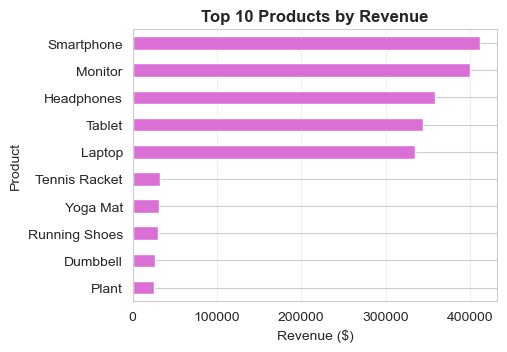

In [20]:
ax1 = plt.subplot(3, 3, 1)
top_10 = df.groupby('Product')['Total_Sale'].sum().nlargest(10).sort_values()
top_10.plot(kind='barh', ax=ax1, color='orchid')
ax1.set_xlabel('Revenue ($)', fontsize=10)
ax1.set_title('Top 10 Products by Revenue', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

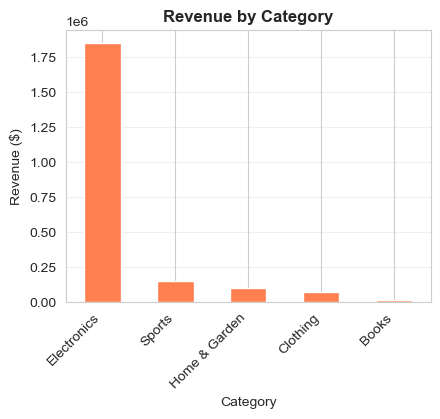

In [21]:
ax2 = plt.subplot(3, 3, 2)
category_analysis['Total_Revenue'].plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Revenue by Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Revenue ($)', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

Text(0, 0.5, '')

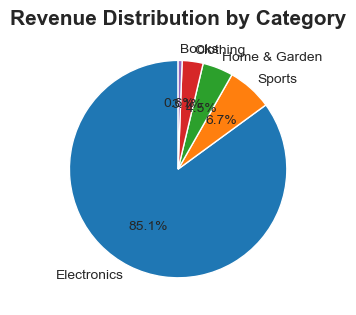

In [22]:
ax3 = plt.subplot(3, 3, 3)
category_analysis['Total_Revenue'].plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Revenue Distribution by Category', fontsize=15, fontweight='bold')
ax3.set_ylabel('')

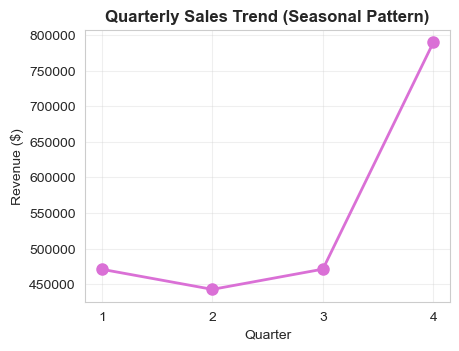

In [23]:
ax4 = plt.subplot(3, 3, 4)
quarterly_data = df.groupby('Quarter')['Total_Sale'].sum()
ax4.plot(quarterly_data.index, quarterly_data.values, marker='o', linewidth=2, markersize=8, color='orchid')
ax4.set_xlabel('Quarter', fontsize=10)
ax4.set_ylabel('Revenue ($)', fontsize=10)
ax4.set_title('Quarterly Sales Trend (Seasonal Pattern)', fontsize=12, fontweight='bold')
ax4.set_xticks([1, 2, 3, 4])
ax4.grid(True, alpha=0.3)

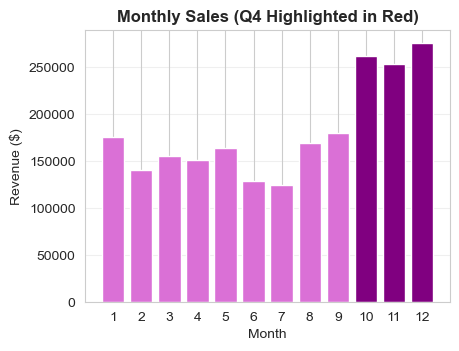

In [24]:
ax5 = plt.subplot(3, 3, 5)
monthly_data = df.groupby('Month')['Total_Sale'].sum()
colors = ['purple' if m in [10, 11, 12] else 'orchid' for m in monthly_data.index]
ax5.bar(monthly_data.index, monthly_data.values, color=colors)
ax5.set_xlabel('Month', fontsize=10)
ax5.set_ylabel('Revenue ($)', fontsize=10)
ax5.set_title('Monthly Sales (Q4 Highlighted in Red)', fontsize=12, fontweight='bold')
ax5.set_xticks(range(1, 13))
ax5.grid(axis='y', alpha=0.3)

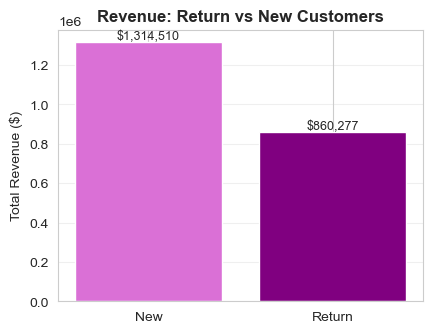

In [36]:
ax6 = plt.subplot(3, 3, 6)
customer_type_revenue = df.groupby('Customer_Type')['Total_Sale'].sum()
bars = ax6.bar(customer_type_revenue.index, customer_type_revenue.values, color=['orchid', 'purple'])
ax6.set_ylabel('Total Revenue ($)', fontsize=10)
ax6.set_title('Revenue: Return vs New Customers', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

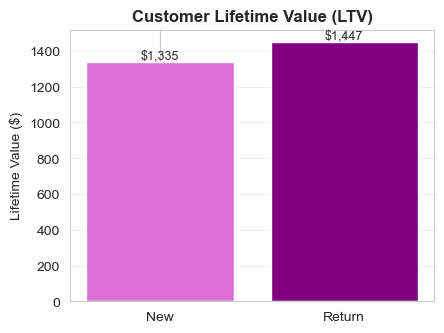

In [26]:
ax8 = plt.subplot(3, 3, 8)
ltv_data = customer_ltv.groupby('Customer_Type')['LTV'].mean()
bars = ax8.bar(ltv_data.index, ltv_data.values, color=['orchid', 'purple'])
ax8.set_ylabel('Lifetime Value ($)', fontsize=10)
ax8.set_title('Customer Lifetime Value (LTV)', fontsize=12, fontweight='bold')
ax8.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

In [31]:
ax9 = plt.subplot(3, 3, 9)
transaction_data = df['Customer_Type'].value_counts()
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax9.pie(transaction_data.values, labels=transaction_data.index,
                                     autopct='%1.1f%%', colors=colors, startangle=90)
ax9.set_title('Transaction Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('E:/PROJECTS/-data-analysis_2/')

print("\n✓ Visualizations saved to: ecommerce_analysis_visualizations.png")
plt.close()


✓ Visualizations saved to: ecommerce_analysis_visualizations.png


In [28]:
print("STEP 8: ACTIONABLE RECOMMENDATIONS")
print("=" * 80)

recommendations = """

📊 KEY FINDINGS:
═════════════════════════════════════════════════════════════════════════════

1. TOP-PERFORMING PRODUCTS:
   • Focus on top 10 products for promotional campaigns
   • Consider bundling complementary products from different categories
   • Ensure adequate inventory for high-revenue products

2. SEASONAL TRENDS:
   • Q4 shows {:.1f}% increase in sales - prepare inventory and staff accordingly
   • Plan marketing campaigns 4-6 weeks before Q4
   • Consider flash sales and discounts during off-peak quarters (Q1-Q3)

3. CUSTOMER INSIGHTS:
   • Return customers generate {:.1f}x higher lifetime value
   • Implement loyalty programs to convert new customers to repeat buyers
   • Retention programs should be a top priority

4. CATEGORY PERFORMANCE:
   • Electronics dominates with {:.1f}% of revenue - maintain premium quality
   • Clothing and Home & Garden show growth potential
   • Sports and Books underperform - consider targeted marketing

═════════════════════════════════════════════════════════════════════════════

🎯 RECOMMENDED ACTIONS:
═════════════════════════════════════════════════════════════════════════════

IMMEDIATE (0-30 days):
  ✓ Create loyalty program to incentivize repeat purchases
  ✓ Stock up inventory for top 10 products
  ✓ Develop targeted email campaigns for return customers
  ✓ Analyze underperforming categories for improvement opportunities

SHORT-TERM (1-3 months):
  ✓ Launch Q4 promotional campaign (start in September)
  ✓ Create product bundles featuring complementary items
  ✓ Implement personalized recommendations based on purchase history
  ✓ Establish seasonal pricing strategy

MEDIUM-TERM (3-6 months):
  ✓ Develop cross-selling strategy between categories
  ✓ Build predictive model for customer churn
  ✓ Expand product lines in high-performing categories
  ✓ Create segmented marketing for different customer types

LONG-TERM (6-12 months):
  ✓ Implement customer lifecycle marketing automation
  ✓ Expand into related product categories
  ✓ Build customer data platform for advanced analytics
  ✓ Develop subscription or membership program for recurring revenue

═════════════════════════════════════════════════════════════════════════════
""".format(q4_increase_pct, ltv_ratio, electronics_pct)

print(recommendations)

STEP 8: ACTIONABLE RECOMMENDATIONS


📊 KEY FINDINGS:
═════════════════════════════════════════════════════════════════════════════

1. TOP-PERFORMING PRODUCTS:
   • Focus on top 10 products for promotional campaigns
   • Consider bundling complementary products from different categories
   • Ensure adequate inventory for high-revenue products

2. SEASONAL TRENDS:
   • Q4 shows 71.2% increase in sales - prepare inventory and staff accordingly
   • Plan marketing campaigns 4-6 weeks before Q4
   • Consider flash sales and discounts during off-peak quarters (Q1-Q3)

3. CUSTOMER INSIGHTS:
   • Return customers generate 1.1x higher lifetime value
   • Implement loyalty programs to convert new customers to repeat buyers
   • Retention programs should be a top priority

4. CATEGORY PERFORMANCE:
   • Electronics dominates with 85.1% of revenue - maintain premium quality
   • Clothing and Home & Garden show growth potential
   • Sports and Books underperform - consider targeted marketing

═════

In [29]:
exports = {
    'top_products': top_products_revenue,
    'category_analysis': category_analysis,
    'quarterly_analysis': quarterly_sales,
    'customer_analysis': customer_analysis,
    'monthly_trends': monthly_sales,
}

In [30]:
import os
from pathlib import Path
output_dir =  'E:/PROJECTS/-data-analysis_2/'

os.makedirs(output_dir, exist_ok=True)

exports = {
    'top_products': top_products_revenue,
    'category_analysis': category_analysis,
    'quarterly_analysis': quarterly_sales,
    'customer_analysis': customer_analysis,
    'monthly_trends': monthly_sales,
}

print("\nExporting CSV files:")
for name, df_to_save in exports.items():
    filepath = f'{output_dir}{name}.csv'
    df_to_save.to_csv(filepath, index=True)
    print(f"   {name}.csv ({len(df_to_save)} rows)")


df.to_csv(f'{output_dir}.csv', index=False)
print(f"csv ({len(df)} rows)")

print(f"Successfully exported {len(exports) + 1} files to:")
print(f"   {output_dir}")




Exporting CSV files:
   top_products.csv (10 rows)
   category_analysis.csv (5 rows)
   quarterly_analysis.csv (4 rows)
   customer_analysis.csv (2 rows)
   monthly_trends.csv (12 rows)
csv (2000 rows)
Successfully exported 6 files to:
   E:/PROJECTS/-data-analysis_2/
